# 02 HD/PD HTA model

This notebook runs the economic evaluation and budget impact analysis for the Singapore haemodialysis (HD) versus peritoneal dialysis (PD).

It uses the model-ready files created by:

`01_process_hd_pd_clinical_cost_data.ipynb`

Main outputs:

1. Five-year cohort Markov cost-utility model.
2. Current-practice versus increased PD uptake comparison.
3. Costs, life-years, QALYs, incremental cost and ICER/dominance interpretation.
4. Five-year budget impact analysis for low, base and high PD adoption scenarios.
5. One-way sensitivity analysis.
6. Threshold analysis for the annual PD cost.
7. Report-ready CSV tables and PNG figures.

Important interpretation:

This is a transparent portfolio model, not an official funding evaluation. Several inputs are assumption-heavy or based on publicly available cost proxies, so the result should be interpreted through uncertainty and scenario analysis rather than as a definitive funding recommendation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# Detect project root whether this notebook is run from:
# 1. HD_PD_HTA_PROJECT/
# 2. HD_PD_HTA_PROJECT/notebooks/
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_PROCESSED = PROJECT_ROOT / "data_processed"
OUTPUTS = PROJECT_ROOT / "outputs"

OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", DATA_PROCESSED)
print("Outputs folder:", OUTPUTS)

Project root: /Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT
Processed data folder: /Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/data_processed
Outputs folder: /Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs


## 1. Load model-ready processed data

The model should not read directly from `data_raw`. Raw files contain source-level information and assumptions. This notebook uses the cleaned `data_processed` layer instead.

In [2]:
REQUIRED_FILES = {
    "base_params": "base_case_parameters_model_ready.csv",
    "state_values": "state_values_model_ready.csv",
    "transition_matrix": "transition_matrix_base_case.csv",
    "bia_scenarios": "budget_impact_scenarios_model_ready.csv",
    "input_quality": "input_quality_flags.csv",
    "validation": "data_validation_summary.csv",
    "sources": "source_inventory.csv",
}

missing = [filename for filename in REQUIRED_FILES.values() if not (DATA_PROCESSED / filename).exists()]
if missing:
    raise FileNotFoundError(f"Missing processed files: {missing}. Run 01_process_hd_pd_clinical_cost_data.ipynb first.")

data = {}
for key, filename in REQUIRED_FILES.items():
    data[key] = pd.read_csv(DATA_PROCESSED / filename)
    print(f"{key:20} {filename:45} rows={len(data[key])}, cols={len(data[key].columns)}")

base_params = data["base_params"]
state_values = data["state_values"]
transition_matrix_raw = data["transition_matrix"]
bia_scenarios = data["bia_scenarios"]
bia_scenarios["year"] = bia_scenarios["year"].astype(int)
input_quality = data["input_quality"]
validation_summary = data["validation"]
source_inventory = data["sources"]

base_params          base_case_parameters_model_ready.csv          rows=19, cols=10
state_values         state_values_model_ready.csv                  rows=4, cols=7
transition_matrix    transition_matrix_base_case.csv               rows=4, cols=5
bia_scenarios        budget_impact_scenarios_model_ready.csv       rows=20, cols=19
input_quality        input_quality_flags.csv                       rows=35, cols=9
validation           data_validation_summary.csv                   rows=24, cols=5
sources              source_inventory.csv                          rows=28, cols=5


In [3]:
# Ensure calendar year is integer before budget impact calculations.
bia_scenarios["year"] = bia_scenarios["year"].astype(int)


## 2. Stop if processed data validation failed

This protects the model from running on known-invalid inputs.

In [4]:
critical_fails = validation_summary.loc[
    (validation_summary["severity"] == "critical") &
    (validation_summary["status"] == "FAIL")
]

if not critical_fails.empty:
    display(critical_fails)
    raise ValueError("Critical validation failures found in data_processed. Fix the inputs before modelling.")

print("No critical validation failures found.")
display(validation_summary.groupby(["severity", "status"]).size().reset_index(name="n_checks"))

No critical validation failures found.


,severity,status,n_checks
0,calculation,PASS,10
1,critical,PASS,9
2,data_quality,PASS,5


## 3. Helper functions

The model is built as a cohort Markov model. A cohort is distributed across health states, then moved through the transition matrix once per annual cycle.

The model currently uses four states:

- `HD`
- `PD`
- `Switched_PD_to_HD`
- `Death`

The `Death` state is absorbing.

In [5]:
def write_output(df: pd.DataFrame, filename: str):
    path = OUTPUTS / filename
    df.to_csv(path, index=False)
    print(f"Wrote {filename}: {len(df)} rows")
    return path

def save_figure(filename: str):
    path = OUTPUTS / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Wrote {filename}")
    plt.show()
    return path

def get_param_value(param_table: pd.DataFrame, parameter: str, value_col: str = "base_value") -> float:
    match = param_table.loc[param_table["parameter"] == parameter, value_col]
    if match.empty:
        raise KeyError(f"Parameter not found: {parameter}")
    return float(match.iloc[0])

def prepare_transition_matrix(matrix_df: pd.DataFrame):
    matrix = matrix_df.set_index("from_state")
    matrix = matrix.astype(float)
    return matrix

def validate_transition_matrix(matrix: pd.DataFrame):
    row_sums = matrix.sum(axis=1)
    if not np.allclose(row_sums.values, 1.0, atol=1e-8):
        raise ValueError(f"Transition matrix rows do not sum to 1: {row_sums.to_dict()}")
    if (matrix < -1e-12).any().any():
        raise ValueError("Transition matrix contains negative probabilities.")
    return True

def make_initial_distribution(pd_uptake: float, states: list, cohort_size: float = 1.0) -> np.ndarray:
    if pd_uptake < 0 or pd_uptake > 1:
        raise ValueError("pd_uptake must be between 0 and 1.")
    dist = pd.Series(0.0, index=states)
    dist["PD"] = cohort_size * pd_uptake
    dist["HD"] = cohort_size * (1 - pd_uptake)
    return dist.values.astype(float)

def simulate_markov(
    initial_distribution: np.ndarray,
    transition_matrix: pd.DataFrame,
    state_values: pd.DataFrame,
    n_cycles: int = 5,
    discount_rate_costs: float = 0.0,
    discount_rate_qalys: float = 0.0,
    strategy_name: str = "strategy",
    half_cycle_correction: bool = False,
):
    # Simulate a cohort Markov model.
    # Costs and QALYs are calculated using occupancy at the start of each annual cycle.
    matrix = transition_matrix.copy()
    validate_transition_matrix(matrix)
    states = list(matrix.index)

    sv = state_values.set_index("health_state").reindex(states)
    if sv.isna().any().any():
        missing = sv.loc[sv.isna().any(axis=1)].index.tolist()
        raise ValueError(f"Missing state values for states: {missing}")

    cost_vector = sv["annual_cost_base"].astype(float).values
    utility_vector = sv["utility_base"].astype(float).values
    alive_vector = np.array([0 if s == "Death" else 1 for s in states], dtype=float)

    dist = np.array(initial_distribution, dtype=float)

    traces = []
    cycle_records = []

    for cycle in range(n_cycles + 1):
        trace_record = {"strategy": strategy_name, "cycle": cycle}
        trace_record.update({state: dist[i] for i, state in enumerate(states)})
        trace_record["cohort_alive"] = float(np.dot(dist, alive_vector))
        trace_record["cohort_dead"] = float(dist[states.index("Death")])
        traces.append(trace_record)

        if cycle < n_cycles:
            next_dist = dist @ matrix.values

            if half_cycle_correction:
                occupancy_for_rewards = (dist + next_dist) / 2
            else:
                occupancy_for_rewards = dist

            cost_discount = 1 / ((1 + discount_rate_costs) ** cycle)
            qaly_discount = 1 / ((1 + discount_rate_qalys) ** cycle)

            undiscounted_cost = float(np.dot(occupancy_for_rewards, cost_vector))
            undiscounted_qalys = float(np.dot(occupancy_for_rewards, utility_vector))
            undiscounted_life_years = float(np.dot(occupancy_for_rewards, alive_vector))

            cycle_records.append({
                "strategy": strategy_name,
                "cycle": cycle + 1,
                "start_cycle": cycle,
                "cost": undiscounted_cost * cost_discount,
                "qalys": undiscounted_qalys * qaly_discount,
                "life_years": undiscounted_life_years * qaly_discount,
                "undiscounted_cost": undiscounted_cost,
                "undiscounted_qalys": undiscounted_qalys,
                "undiscounted_life_years": undiscounted_life_years,
                "discount_factor_costs": cost_discount,
                "discount_factor_qalys": qaly_discount
            })

            dist = next_dist

    trace_df = pd.DataFrame(traces)
    cycle_df = pd.DataFrame(cycle_records)

    summary = {
        "strategy": strategy_name,
        "total_cost": cycle_df["cost"].sum(),
        "total_qalys": cycle_df["qalys"].sum(),
        "total_life_years": cycle_df["life_years"].sum(),
        "undiscounted_total_cost": cycle_df["undiscounted_cost"].sum(),
        "undiscounted_total_qalys": cycle_df["undiscounted_qalys"].sum(),
        "undiscounted_total_life_years": cycle_df["undiscounted_life_years"].sum(),
        "final_alive": trace_df.iloc[-1]["cohort_alive"],
        "final_dead": trace_df.iloc[-1]["cohort_dead"],
        "half_cycle_correction": half_cycle_correction,
        "discount_rate_costs": discount_rate_costs,
        "discount_rate_qalys": discount_rate_qalys,
        "n_cycles": n_cycles
    }

    return trace_df, cycle_df, pd.DataFrame([summary])




def compare_strategies(summary_df: pd.DataFrame, intervention: str, comparator: str):
    comp = summary_df.loc[summary_df["strategy"] == comparator].iloc[0]
    intv = summary_df.loc[summary_df["strategy"] == intervention].iloc[0]

    inc_cost = intv["total_cost"] - comp["total_cost"]
    inc_qalys = intv["total_qalys"] - comp["total_qalys"]
    inc_life_years = intv["total_life_years"] - comp["total_life_years"]

    if inc_cost < 0 and inc_qalys > 0:
        interpretation = "Dominant: lower cost and higher QALYs"
        icer = np.nan
    elif inc_cost > 0 and inc_qalys < 0:
        interpretation = "Dominated: higher cost and lower QALYs"
        icer = np.nan
    elif inc_cost < 0 and inc_qalys < 0:
        icer = inc_cost / inc_qalys
        interpretation = "Trade-off: lower cost but fewer QALYs; ICER reflects cost saved per QALY lost"
    elif inc_cost > 0 and inc_qalys > 0:
        icer = inc_cost / inc_qalys
        interpretation = "Trade-off: higher cost and higher QALYs; ICER reflects cost per QALY gained"
    elif np.isclose(inc_qalys, 0) and inc_cost < 0:
        icer = np.nan
        interpretation = "Cost-saving with no meaningful QALY difference"
    elif np.isclose(inc_qalys, 0) and inc_cost > 0:
        icer = np.nan
        interpretation = "Higher cost with no meaningful QALY difference"
    elif np.isclose(inc_cost, 0) and inc_qalys > 0:
        icer = np.nan
        interpretation = "Similar cost with higher QALYs"
    elif np.isclose(inc_cost, 0) and inc_qalys < 0:
        icer = np.nan
        interpretation = "Similar cost with fewer QALYs"
    else:
        icer = np.nan
        interpretation = "Ambiguous result; inspect incremental cost and QALYs directly"

    return pd.DataFrame([{
        "intervention": intervention,
        "comparator": comparator,
        "incremental_cost": inc_cost,
        "incremental_qalys": inc_qalys,
        "incremental_life_years": inc_life_years,
        "icer_cost_per_qaly": icer,
        "interpretation": interpretation
    }])

## 4. Inspect base-case inputs

Before running the model, inspect the values that matter most:

- Current PD uptake: 19%
- Target PD uptake: 30%
- Annual HD cost
- Annual blended PD cost
- Utility values
- Transition matrix

In [6]:
transition_matrix = prepare_transition_matrix(transition_matrix_raw)
validate_transition_matrix(transition_matrix)

time_horizon_years = int(get_param_value(base_params, "time_horizon_years"))
current_pd_uptake = get_param_value(base_params, "current_pd_uptake")
target_pd_uptake = get_param_value(base_params, "target_pd_uptake")
eligible_patients_per_year = get_param_value(base_params, "eligible_patients_per_year")

print("Time horizon:", time_horizon_years)
print("Current PD uptake:", current_pd_uptake)
print("Target PD uptake:", target_pd_uptake)
print("Eligible patients per year:", eligible_patients_per_year)

print("\nState values:")
display(state_values)

print("\nBase-case transition matrix:")
display(transition_matrix)

print("\nKey input quality flags:")
display(input_quality.loc[
    input_quality["parameter"].isin([
        "hd_annual_cost",
        "pd_blended_annual_cost",
        "health_state_utility_hd",
        "health_state_utility_pd",
        "annual_death_probability_hd",
        "annual_death_probability_pd",
        "annual_pd_to_hd_switch_probability"
    ])
])

Time horizon: 5
Current PD uptake: 0.19
Target PD uptake: 0.3
Eligible patients per year: 1314.0

State values:


,health_state,annual_cost_base,annual_cost_low,annual_cost_high,utility_base,utility_low,utility_high
0,Death,0.0,0.0,0.0,0.00,0.00,0.00
1,HD,37800.0,33600.0,42000.0,0.58,0.44,0.71
2,PD,18840.0,16800.0,20700.0,0.62,0.53,0.72
3,Switched_PD_to_HD,37800.0,33600.0,42000.0,0.56,0.44,0.71



Base-case transition matrix:


,HD,PD,Switched_PD_to_HD,Death
from_state,,,,
HD,0.87,0.01,0.00,0.12
PD,0.00,0.73,0.15,0.12
Switched_PD_to_HD,0.00,0.00,0.88,0.12
Death,0.00,0.00,0.00,1.00



Key input quality flags:


,table,parameter,base_value,low_value,high_value,unit,source_key,input_quality_flag,notes
12,costs,hd_annual_cost,37800.00,33600.00,42000.00,SGD_per_year,DUKE_MYKIDNEY_COSTS,Derived input,Derived from monthly HD cost.
18,costs,pd_blended_annual_cost,18840.00,16800.00,20700.00,SGD_per_year,KHAN_2022_ECONOMICS,Derived input,Base annual PD cost used in the simplified two...
25,utilities,health_state_utility_hd,0.58,0.44,0.71,utility_weight,COOPER_2020_UTILITIES,High uncertainty / assumption,Placeholder utility for first-pass model. Coop...
26,utilities,health_state_utility_pd,0.62,0.53,0.72,utility_weight,YANG_2018_PD_HRQoL,High uncertainty / assumption,Placeholder utility for first-pass model. Keep...
29,transitions,annual_death_probability_hd,0.12,0.08,0.18,annual_probability,KHOO_2022_OUTCOMES,High uncertainty / assumption,Base case assumes equal annual mortality for H...
30,transitions,annual_death_probability_pd,0.12,0.08,0.20,annual_probability,KHOO_2022_OUTCOMES,High uncertainty / assumption,Base case assumes equal mortality. Scenario an...
32,transitions,annual_pd_to_hd_switch_probability,0.15,0.08,0.25,annual_probability,KHAN_2022_ECONOMICS,High uncertainty / assumption,Represents PD technique failure or modality sw...


## 5. Base-case economic evaluation

The base-case economic evaluation compares:

- **Current practice:** 19% PD and 81% HD among medically suitable new dialysis patients.
- **Increased PD uptake:** 30% PD and 70% HD among medically suitable new dialysis patients.

The base model uses a five-year horizon and annual cycles. Discounting is set to 0% in the first run because the project is using a short portfolio horizon and the final discounting assumption should be confirmed before the report is finalised.

In [7]:
BASE_DISCOUNT_COSTS = 0.0
BASE_DISCOUNT_QALYS = 0.0
HALF_CYCLE_CORRECTION = False

states = list(transition_matrix.index)

initial_current = make_initial_distribution(current_pd_uptake, states, cohort_size=1.0)
initial_target = make_initial_distribution(target_pd_uptake, states, cohort_size=1.0)

trace_current, cycles_current, summary_current = simulate_markov(
    initial_distribution=initial_current,
    transition_matrix=transition_matrix,
    state_values=state_values,
    n_cycles=time_horizon_years,
    discount_rate_costs=BASE_DISCOUNT_COSTS,
    discount_rate_qalys=BASE_DISCOUNT_QALYS,
    strategy_name="current_practice",
    half_cycle_correction=HALF_CYCLE_CORRECTION
)

trace_target, cycles_target, summary_target = simulate_markov(
    initial_distribution=initial_target,
    transition_matrix=transition_matrix,
    state_values=state_values,
    n_cycles=time_horizon_years,
    discount_rate_costs=BASE_DISCOUNT_COSTS,
    discount_rate_qalys=BASE_DISCOUNT_QALYS,
    strategy_name="increased_pd_uptake",
    half_cycle_correction=HALF_CYCLE_CORRECTION
)

trace_base = pd.concat([trace_current, trace_target], ignore_index=True)
cycles_base = pd.concat([cycles_current, cycles_target], ignore_index=True)
summary_base = pd.concat([summary_current, summary_target], ignore_index=True)

ce_comparison_base = compare_strategies(
    summary_base,
    intervention="increased_pd_uptake",
    comparator="current_practice"
)

write_output(trace_base, "markov_trace_base_case.csv")
write_output(cycles_base, "markov_cycle_outputs_base_case.csv")
write_output(summary_base, "economic_evaluation_summary_base_case.csv")
write_output(ce_comparison_base, "economic_evaluation_incremental_results_base_case.csv")

display(summary_base.round(4))
display(ce_comparison_base.round(4))

Wrote markov_trace_base_case.csv: 12 rows
Wrote markov_cycle_outputs_base_case.csv: 10 rows
Wrote economic_evaluation_summary_base_case.csv: 2 rows
Wrote economic_evaluation_incremental_results_base_case.csv: 1 rows


,strategy,total_cost,total_qalys,total_life_years,undiscounted_total_cost,undiscounted_total_qalys,undiscounted_total_life_years,final_alive,final_dead,half_cycle_correction,discount_rate_costs,discount_rate_qalys,n_cycles
0,current_practice,137176.3144,2.3031,3.9356,137176.3144,2.3031,3.9356,0.5277,0.4723,False,0.0,0.0,5
1,increased_pd_uptake,131190.6140,2.3135,3.9356,131190.6140,2.3135,3.9356,0.5277,0.4723,False,0.0,0.0,5


,intervention,comparator,incremental_cost,incremental_qalys,incremental_life_years,icer_cost_per_qaly,interpretation
0,increased_pd_uptake,current_practice,-5985.7004,0.0105,0.0,NaN,Dominant: lower cost and higher QALYs


## 6. Scale base-case results to the eligible annual cohort

The previous section reports results per eligible patient. This section scales the same Markov result to one annual eligible cohort.

This is useful for report interpretation, but it is not the same as the full five-year budget impact analysis, which accounts for multiple annual cohorts entering over time.

In [8]:
summary_scaled = summary_base.copy()
numeric_cols = [
    "total_cost", "total_qalys", "total_life_years",
    "undiscounted_total_cost", "undiscounted_total_qalys", "undiscounted_total_life_years",
    "final_alive", "final_dead"
]

for col in numeric_cols:
    summary_scaled[col] = summary_scaled[col] * eligible_patients_per_year

summary_scaled["scale"] = f"One eligible annual cohort of {eligible_patients_per_year:,.0f} patients"

comparison_scaled = compare_strategies(
    summary_scaled,
    intervention="increased_pd_uptake",
    comparator="current_practice"
)

write_output(summary_scaled, "economic_evaluation_summary_scaled_annual_cohort.csv")
write_output(comparison_scaled, "economic_evaluation_incremental_results_scaled_annual_cohort.csv")

display(summary_scaled.round(2))
display(comparison_scaled.round(2))

Wrote economic_evaluation_summary_scaled_annual_cohort.csv: 2 rows
Wrote economic_evaluation_incremental_results_scaled_annual_cohort.csv: 1 rows


,strategy,total_cost,total_qalys,total_life_years,undiscounted_total_cost,undiscounted_total_qalys,undiscounted_total_life_years,final_alive,final_dead,half_cycle_correction,discount_rate_costs,discount_rate_qalys,n_cycles,scale
0,current_practice,1.802497e+08,3026.26,5171.34,1.802497e+08,3026.26,5171.34,693.44,620.56,False,0.0,0.0,5,"One eligible annual cohort of 1,314 patients"
1,increased_pd_uptake,1.723845e+08,3040.00,5171.34,1.723845e+08,3040.00,5171.34,693.44,620.56,False,0.0,0.0,5,"One eligible annual cohort of 1,314 patients"


,intervention,comparator,incremental_cost,incremental_qalys,incremental_life_years,icer_cost_per_qaly,interpretation
0,increased_pd_uptake,current_practice,-7865210.31,13.74,0.0,NaN,Dominant: lower cost and higher QALYs


## 7. Base-case Markov trace figures

These figures show how the cohort moves across health states over five years.



Wrote figure_markov_trace_current_practice.png


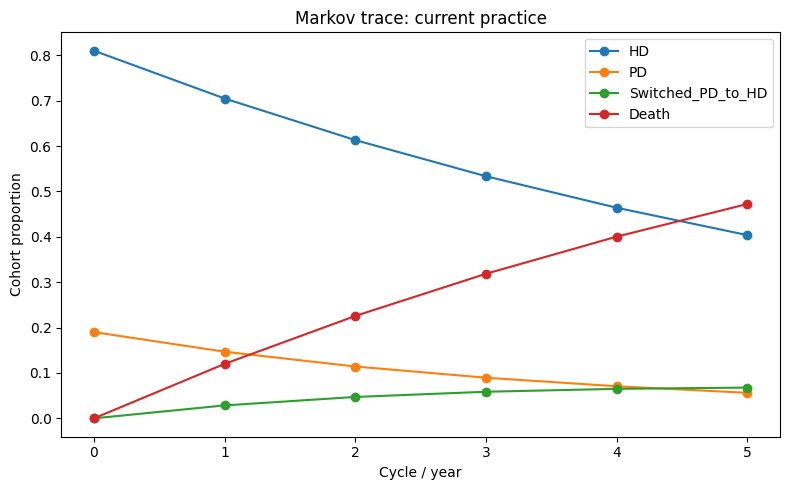

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_markov_trace_current_practice.png')

In [9]:
plot_df = trace_current.set_index("cycle")[states]
plt.figure(figsize=(8, 5))
for state in states:
    plt.plot(plot_df.index, plot_df[state], marker="o", label=state)
plt.xlabel("Cycle / year")
plt.ylabel("Cohort proportion")
plt.title("Markov trace: current practice")
plt.legend()
save_figure("figure_markov_trace_current_practice.png")

Wrote figure_markov_trace_increased_pd_uptake.png


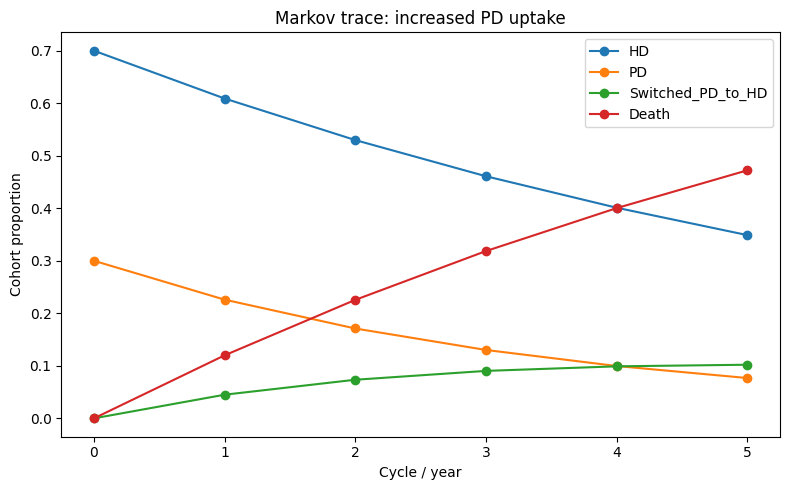

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_markov_trace_increased_pd_uptake.png')

In [10]:
plot_df = trace_target.set_index("cycle")[states]
plt.figure(figsize=(8, 5))
for state in states:
    plt.plot(plot_df.index, plot_df[state], marker="o", label=state)
plt.xlabel("Cycle / year")
plt.ylabel("Cohort proportion")
plt.title("Markov trace: increased PD uptake")
plt.legend()
save_figure("figure_markov_trace_increased_pd_uptake.png")

Wrote figure_cost_per_patient_base_case.png


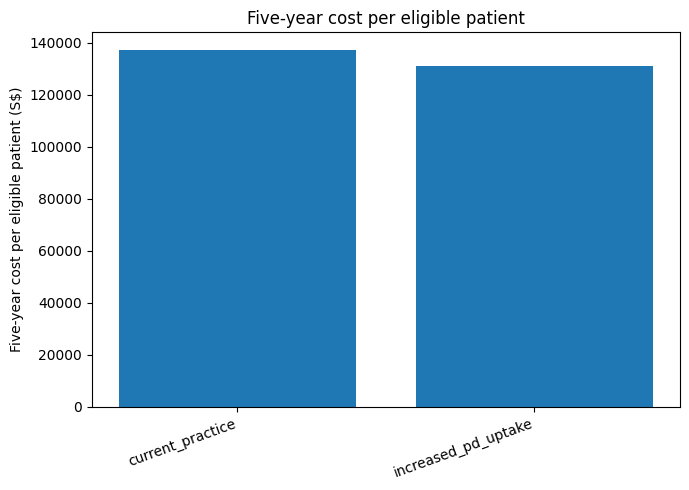

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_cost_per_patient_base_case.png')

In [11]:
cost_plot = summary_base[["strategy", "total_cost"]].copy()
plt.figure(figsize=(7, 5))
plt.bar(cost_plot["strategy"], cost_plot["total_cost"])
plt.ylabel("Five-year cost per eligible patient (S$)")
plt.title("Five-year cost per eligible patient")
plt.xticks(rotation=20, ha="right")
save_figure("figure_cost_per_patient_base_case.png")

Wrote figure_qalys_per_patient_base_case.png


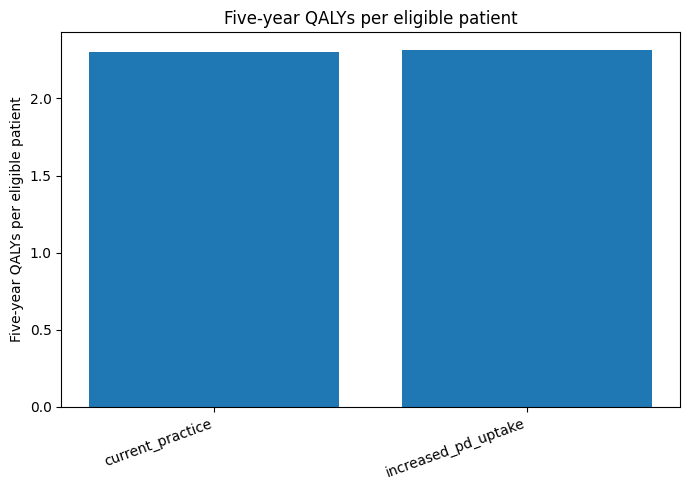

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_qalys_per_patient_base_case.png')

In [12]:
qaly_plot = summary_base[["strategy", "total_qalys"]].copy()
plt.figure(figsize=(7, 5))
plt.bar(qaly_plot["strategy"], qaly_plot["total_qalys"])
plt.ylabel("Five-year QALYs per eligible patient")
plt.title("Five-year QALYs per eligible patient")
plt.xticks(rotation=20, ha="right")
save_figure("figure_qalys_per_patient_base_case.png")

## 8. Five-year budget impact analysis

The budget impact analysis compares current practice with three adoption scenarios:

- `low_pd_adoption`
- `base_pd_adoption`
- `high_pd_adoption`

This BIA uses overlapping annual incident cohorts. For each calendar year, the model adds costs from:

1. the new cohort entering that year,
2. previous cohorts still alive and receiving dialysis.

In [13]:
def simulate_cohort_yearly_costs(
    pd_uptake: float,
    cohort_size: float,
    transition_matrix: pd.DataFrame,
    state_values: pd.DataFrame,
    max_cycles: int,
    strategy_name: str,
    cohort_start_year: int,
):
    initial = make_initial_distribution(pd_uptake, list(transition_matrix.index), cohort_size=cohort_size)
    trace, cycles, summary = simulate_markov(
        initial_distribution=initial,
        transition_matrix=transition_matrix,
        state_values=state_values,
        n_cycles=max_cycles,
        discount_rate_costs=0.0,
        discount_rate_qalys=0.0,
        strategy_name=strategy_name,
        half_cycle_correction=False
    )
    cycles["cohort_start_year"] = cohort_start_year
    cycles["calendar_year"] = cohort_start_year + cycles["start_cycle"]
    cycles["pd_uptake_at_start"] = pd_uptake
    cycles["cohort_size"] = cohort_size
    return trace, cycles, summary

def run_budget_impact_analysis(
    bia_scenarios: pd.DataFrame,
    transition_matrix: pd.DataFrame,
    state_values: pd.DataFrame,
    scenario_names: list,
):
    years = sorted(bia_scenarios["year"].astype(int).unique())
    current_rows = bia_scenarios.loc[bia_scenarios["scenario"] == "current_practice"].copy()

    all_annual = []
    all_cohort_cycles = []

    for scenario in scenario_names:
        scenario_rows = bia_scenarios.loc[bia_scenarios["scenario"] == scenario].copy()
        scenario_cycles = []
        current_cycles = []

        for _, row in scenario_rows.iterrows():
            start_year = int(row["year"])
            remaining_cycles = int(max(years) - start_year + 1)
            cohort_size = float(row["eligible_patients_per_year"])
            pd_uptake = float(row["pd_uptake"])

            _, cycles_s, _ = simulate_cohort_yearly_costs(
                pd_uptake=pd_uptake,
                cohort_size=cohort_size,
                transition_matrix=transition_matrix,
                state_values=state_values,
                max_cycles=remaining_cycles,
                strategy_name=scenario,
                cohort_start_year=start_year
            )
            scenario_cycles.append(cycles_s)

            current_match = current_rows.loc[current_rows["year"] == start_year].iloc[0]
            _, cycles_c, _ = simulate_cohort_yearly_costs(
                pd_uptake=float(current_match["pd_uptake"]),
                cohort_size=float(current_match["eligible_patients_per_year"]),
                transition_matrix=transition_matrix,
                state_values=state_values,
                max_cycles=remaining_cycles,
                strategy_name="current_practice",
                cohort_start_year=start_year
            )
            current_cycles.append(cycles_c)

        scenario_cycles_df = pd.concat(scenario_cycles, ignore_index=True)
        current_cycles_df = pd.concat(current_cycles, ignore_index=True)

        scenario_annual = scenario_cycles_df.groupby("calendar_year", as_index=False).agg(
            scenario_cost=("cost", "sum"),
            scenario_qalys=("qalys", "sum"),
            scenario_life_years=("life_years", "sum")
        )
        current_annual = current_cycles_df.groupby("calendar_year", as_index=False).agg(
            current_cost=("cost", "sum"),
            current_qalys=("qalys", "sum"),
            current_life_years=("life_years", "sum")
        )

        annual = scenario_annual.merge(current_annual, on="calendar_year", how="outer").fillna(0)
        annual["scenario"] = scenario
        annual["incremental_cost"] = annual["scenario_cost"] - annual["current_cost"]
        annual["incremental_qalys"] = annual["scenario_qalys"] - annual["current_qalys"]
        annual["incremental_life_years"] = annual["scenario_life_years"] - annual["current_life_years"]
        annual["cumulative_incremental_cost"] = annual["incremental_cost"].cumsum()
        annual["cumulative_incremental_qalys"] = annual["incremental_qalys"].cumsum()

        all_annual.append(annual)

        scenario_cycles_df["comparison_group"] = "scenario"
        current_cycles_df["comparison_group"] = "current_practice"
        scenario_cycles_df["bia_scenario"] = scenario
        current_cycles_df["bia_scenario"] = scenario
        all_cohort_cycles.append(pd.concat([scenario_cycles_df, current_cycles_df], ignore_index=True))

    annual_results = pd.concat(all_annual, ignore_index=True)
    cohort_cycle_results = pd.concat(all_cohort_cycles, ignore_index=True)

    cumulative_summary = annual_results.groupby("scenario", as_index=False).agg(
        five_year_incremental_cost=("incremental_cost", "sum"),
        five_year_incremental_qalys=("incremental_qalys", "sum"),
        five_year_incremental_life_years=("incremental_life_years", "sum"),
        year_5_incremental_cost=("incremental_cost", "last"),
        year_5_cumulative_incremental_cost=("cumulative_incremental_cost", "last")
    )

    return annual_results, cumulative_summary, cohort_cycle_results

scenario_names = ["low_pd_adoption", "base_pd_adoption", "high_pd_adoption"]

bia_annual_results, bia_cumulative_summary, bia_cohort_cycle_results = run_budget_impact_analysis(
    bia_scenarios=bia_scenarios,
    transition_matrix=transition_matrix,
    state_values=state_values,
    scenario_names=scenario_names
)

write_output(bia_annual_results, "budget_impact_annual_results.csv")
write_output(bia_cumulative_summary, "budget_impact_cumulative_summary.csv")
write_output(bia_cohort_cycle_results, "budget_impact_cohort_cycle_details.csv")

display(bia_annual_results.round(2))
display(bia_cumulative_summary.round(2))

Wrote budget_impact_annual_results.csv: 15 rows
Wrote budget_impact_cumulative_summary.csv: 3 rows
Wrote budget_impact_cohort_cycle_details.csv: 90 rows


,calendar_year,scenario_cost,scenario_qalys,scenario_life_years,current_cost,current_qalys,current_life_years,scenario,incremental_cost,incremental_qalys,incremental_life_years,cumulative_incremental_cost,cumulative_incremental_qalys
0,2026,4.443738e+07,773.16,1314.00,4.493565e+07,772.11,1314.00,low_pd_adoption,-498268.80,1.05,-0.0,-498268.80,1.05
1,2027,8.363196e+07,1452.52,2470.32,8.498725e+07,1449.74,2470.32,low_pd_adoption,-1355291.14,2.78,-0.0,-1853559.94,3.83
2,2028,1.181358e+08,2049.62,3487.88,1.206057e+08,2044.69,3487.88,low_pd_adoption,-2469868.61,4.93,-0.0,-4323428.55,8.76
3,2029,1.487044e+08,2574.00,4383.34,1.522240e+08,2567.22,4383.34,low_pd_adoption,-3519555.55,6.78,-0.0,-7842984.10,15.54
4,2030,1.757286e+08,3034.68,5171.34,1.802497e+08,3026.26,5171.34,low_pd_adoption,-4521082.62,8.42,-0.0,-12364066.72,23.96
5,2026,4.418824e+07,773.68,1314.00,4.493565e+07,772.11,1314.00,base_pd_adoption,-747403.20,1.58,-0.0,-747403.20,1.58
6,2027,8.320345e+07,1453.38,2470.32,8.498725e+07,1449.74,2470.32,base_pd_adoption,-1783802.30,3.65,-0.0,-2531205.50,5.22
7,2028,1.175785e+08,2050.69,3487.88,1.206057e+08,2044.69,3487.88,base_pd_adoption,-3027157.35,6.00,-0.0,-5558362.86,11.22
8,2029,1.478059e+08,2575.72,4383.34,1.522240e+08,2567.22,4383.34,base_pd_adoption,-4418100.62,8.50,-0.0,-9976463.48,19.72
9,2030,1.743359e+08,3037.32,5171.34,1.802497e+08,3026.26,5171.34,base_pd_adoption,-5913747.31,11.06,-0.0,-15890210.78,30.78


,scenario,five_year_incremental_cost,five_year_incremental_qalys,five_year_incremental_life_years,year_5_incremental_cost,year_5_cumulative_incremental_cost
0,base_pd_adoption,-15890210.78,30.78,-0.0,-5913747.31,-15890210.78
1,high_pd_adoption,-32737986.58,63.30,-0.0,-11799259.71,-32737986.58
2,low_pd_adoption,-12364066.72,23.96,-0.0,-4521082.62,-12364066.72


## 9. Budget impact figures

These figures should feed directly into the report results section.

Wrote figure_annual_budget_impact.png


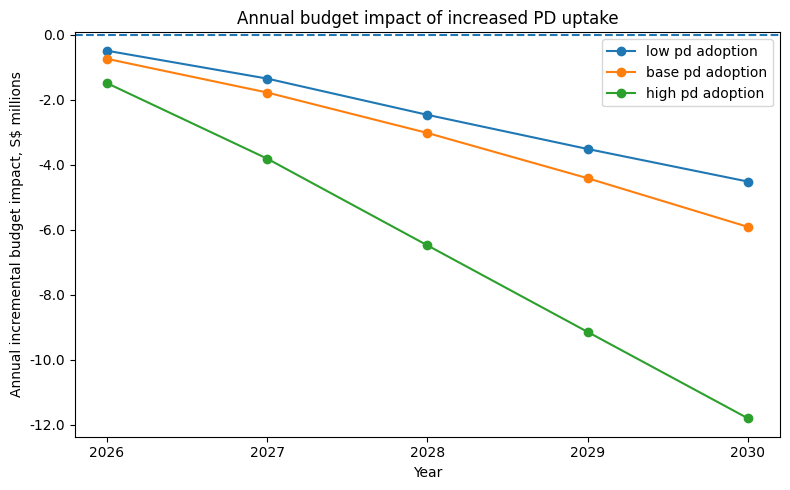

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_annual_budget_impact.png')

In [14]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    return f"{x/1_000_000:.1f}"

scenario_order = ["low_pd_adoption", "base_pd_adoption", "high_pd_adoption"]

plt.figure(figsize=(8, 5))
for scenario in scenario_order:
    plot_df = bia_annual_results.loc[bia_annual_results["scenario"] == scenario].copy()
    plot_df["calendar_year"] = plot_df["calendar_year"].astype(int)
    plot_df = plot_df.sort_values("calendar_year")
    plt.plot(
        plot_df["calendar_year"],
        plot_df["incremental_cost"],
        marker="o",
        label=scenario.replace("_", " ")
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Annual incremental budget impact, S$ millions")
plt.title("Annual budget impact of increased PD uptake")
plt.xticks(sorted(bia_annual_results["calendar_year"].astype(int).unique()))
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.legend()
save_figure("figure_annual_budget_impact.png")

Wrote figure_cumulative_budget_impact.png


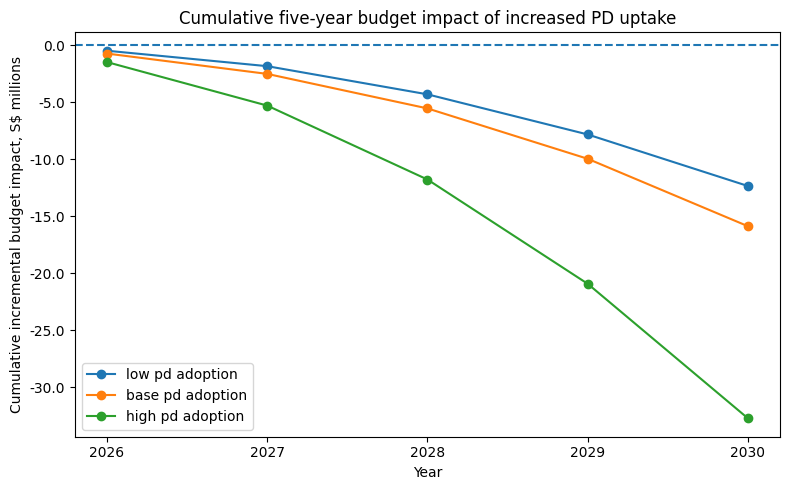

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_cumulative_budget_impact.png')

In [15]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    return f"{x/1_000_000:.1f}"

scenario_order = ["low_pd_adoption", "base_pd_adoption", "high_pd_adoption"]

plt.figure(figsize=(8, 5))
for scenario in scenario_order:
    plot_df = bia_annual_results.loc[bia_annual_results["scenario"] == scenario].copy()
    plot_df["calendar_year"] = plot_df["calendar_year"].astype(int)
    plot_df = plot_df.sort_values("calendar_year")
    plt.plot(
        plot_df["calendar_year"],
        plot_df["cumulative_incremental_cost"],
        marker="o",
        label=scenario.replace("_", " ")
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Cumulative incremental budget impact, S$ millions")
plt.title("Cumulative five-year budget impact of increased PD uptake")
plt.xticks(sorted(bia_annual_results["calendar_year"].astype(int).unique()))
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.legend()
save_figure("figure_cumulative_budget_impact.png")

Wrote figure_five_year_budget_impact_by_scenario.png


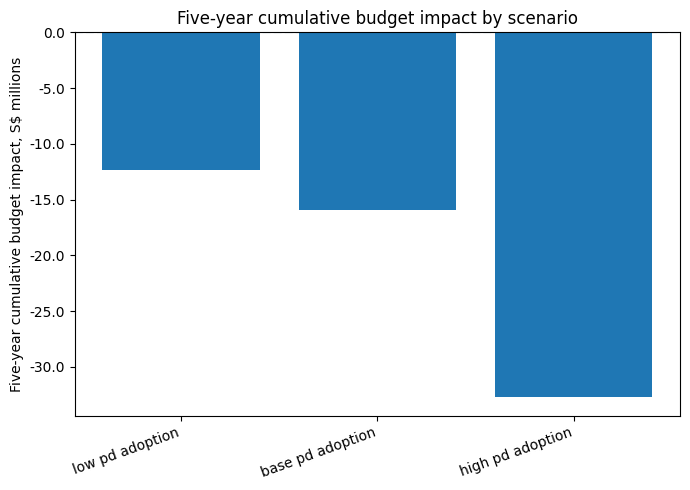

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_five_year_budget_impact_by_scenario.png')

In [16]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    return f"{x/1_000_000:.1f}"

scenario_order = ["low_pd_adoption", "base_pd_adoption", "high_pd_adoption"]

plot_df = (
    bia_cumulative_summary
    .set_index("scenario")
    .loc[scenario_order]
    .reset_index()
)

plot_df["scenario_label"] = plot_df["scenario"].str.replace("_", " ")

plt.figure(figsize=(7, 5))
plt.bar(plot_df["scenario_label"], plot_df["five_year_incremental_cost"])
plt.axhline(0, linestyle="--")
plt.ylabel("Five-year cumulative budget impact, S$ millions")
plt.title("Five-year cumulative budget impact by scenario")
plt.xticks(rotation=20, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
save_figure("figure_five_year_budget_impact_by_scenario.png")

## 10. Scenario analysis: 3% discounting and half-cycle correction

This section tests whether technical modelling choices change the conclusion.

In [17]:
def run_two_strategy_model(discount_rate_costs=0.0, discount_rate_qalys=0.0, half_cycle_correction=False):
    tr_c, cy_c, sum_c = simulate_markov(
        initial_distribution=initial_current,
        transition_matrix=transition_matrix,
        state_values=state_values,
        n_cycles=time_horizon_years,
        discount_rate_costs=discount_rate_costs,
        discount_rate_qalys=discount_rate_qalys,
        strategy_name="current_practice",
        half_cycle_correction=half_cycle_correction
    )
    tr_t, cy_t, sum_t = simulate_markov(
        initial_distribution=initial_target,
        transition_matrix=transition_matrix,
        state_values=state_values,
        n_cycles=time_horizon_years,
        discount_rate_costs=discount_rate_costs,
        discount_rate_qalys=discount_rate_qalys,
        strategy_name="increased_pd_uptake",
        half_cycle_correction=half_cycle_correction
    )
    summary = pd.concat([sum_c, sum_t], ignore_index=True)
    comparison = compare_strategies(summary, "increased_pd_uptake", "current_practice")
    return summary, comparison

scenario_records = []

technical_scenarios = [
    ("base_case_no_discount_no_hcc", 0.0, 0.0, False),
    ("discount_3_percent_no_hcc", 0.03, 0.03, False),
    ("no_discount_with_hcc", 0.0, 0.0, True),
    ("discount_3_percent_with_hcc", 0.03, 0.03, True),
]

for name, dr_c, dr_q, hcc in technical_scenarios:
    summary_s, comp_s = run_two_strategy_model(
        discount_rate_costs=dr_c,
        discount_rate_qalys=dr_q,
        half_cycle_correction=hcc
    )
    row = comp_s.iloc[0].to_dict()
    row["technical_scenario"] = name
    row["discount_rate_costs"] = dr_c
    row["discount_rate_qalys"] = dr_q
    row["half_cycle_correction"] = hcc
    scenario_records.append(row)

technical_scenario_results = pd.DataFrame(scenario_records)
write_output(technical_scenario_results, "technical_scenario_results.csv")
display(technical_scenario_results.round(4))

Wrote technical_scenario_results.csv: 4 rows


,intervention,comparator,incremental_cost,incremental_qalys,incremental_life_years,icer_cost_per_qaly,interpretation,technical_scenario,discount_rate_costs,discount_rate_qalys,half_cycle_correction
0,increased_pd_uptake,current_practice,-5985.7004,0.0105,0.0,NaN,Dominant: lower cost and higher QALYs,base_case_no_discount_no_hcc,0.00,0.00,False
1,increased_pd_uptake,current_practice,-5753.3908,0.0101,0.0,NaN,Dominant: lower cost and higher QALYs,discount_3_percent_no_hcc,0.03,0.03,False
2,increased_pd_uptake,current_practice,-5137.3965,0.0083,0.0,NaN,Dominant: lower cost and higher QALYs,no_discount_with_hcc,0.00,0.00,True
3,increased_pd_uptake,current_practice,-4938.4150,0.0081,0.0,NaN,Dominant: lower cost and higher QALYs,discount_3_percent_with_hcc,0.03,0.03,True


## 11. One-way sensitivity analysis

This section varies one uncertain input at a time across its low and high values.

Because the base-case result may be dominant rather than expressed as a conventional ICER, the main sensitivity output focuses on:

- incremental cost,
- incremental QALYs,
- dominance interpretation.

The tornado chart uses incremental cost because this is the clearest driver for this project.

In [18]:
def rebuild_transition_matrix(
    p_death_hd=None,
    p_death_pd=None,
    p_pd_to_hd=None,
    p_hd_to_pd=None
):
    p_death_hd = get_param_value(base_params, "annual_death_probability_hd") if p_death_hd is None else p_death_hd
    p_death_pd = get_param_value(base_params, "annual_death_probability_pd") if p_death_pd is None else p_death_pd
    p_pd_to_hd = get_param_value(base_params, "annual_pd_to_hd_switch_probability") if p_pd_to_hd is None else p_pd_to_hd
    p_hd_to_pd = get_param_value(base_params, "annual_hd_to_pd_switch_probability") if p_hd_to_pd is None else p_hd_to_pd

    tm = pd.DataFrame(0.0, index=states, columns=states)
    tm.loc["HD", "PD"] = p_hd_to_pd
    tm.loc["HD", "Death"] = p_death_hd
    tm.loc["HD", "HD"] = 1 - p_hd_to_pd - p_death_hd

    tm.loc["PD", "Switched_PD_to_HD"] = p_pd_to_hd
    tm.loc["PD", "Death"] = p_death_pd
    tm.loc["PD", "PD"] = 1 - p_pd_to_hd - p_death_pd

    tm.loc["Switched_PD_to_HD", "Death"] = p_death_hd
    tm.loc["Switched_PD_to_HD", "Switched_PD_to_HD"] = 1 - p_death_hd

    tm.loc["Death", "Death"] = 1.0
    validate_transition_matrix(tm)
    return tm

def update_state_values(
    annual_cost_hd=None,
    annual_cost_pd=None,
    annual_cost_switched=None,
    utility_hd=None,
    utility_pd=None,
    utility_switched=None
):
    sv = state_values.copy()

    def set_state_value(state, column, value):
        if value is not None:
            sv.loc[sv["health_state"] == state, column] = value

    set_state_value("HD", "annual_cost_base", annual_cost_hd)
    set_state_value("PD", "annual_cost_base", annual_cost_pd)
    set_state_value("Switched_PD_to_HD", "annual_cost_base", annual_cost_switched)

    set_state_value("HD", "utility_base", utility_hd)
    set_state_value("PD", "utility_base", utility_pd)
    set_state_value("Switched_PD_to_HD", "utility_base", utility_switched)

    return sv

def evaluate_with_overrides(parameter_name=None, value=None):
    tm = transition_matrix.copy()
    sv = state_values.copy()

    if parameter_name == "annual_cost_hd":
        sv = update_state_values(annual_cost_hd=value, annual_cost_switched=value)
    elif parameter_name == "annual_cost_pd":
        sv = update_state_values(annual_cost_pd=value)
    elif parameter_name == "annual_cost_switched_pd_to_hd":
        sv = update_state_values(annual_cost_switched=value)
    elif parameter_name == "health_state_utility_hd":
        sv = update_state_values(utility_hd=value)
    elif parameter_name == "health_state_utility_pd":
        sv = update_state_values(utility_pd=value)
    elif parameter_name == "health_state_utility_switched_pd_to_hd":
        sv = update_state_values(utility_switched=value)
    elif parameter_name == "annual_death_probability_hd":
        tm = rebuild_transition_matrix(p_death_hd=value)
    elif parameter_name == "annual_death_probability_pd":
        tm = rebuild_transition_matrix(p_death_pd=value)
    elif parameter_name == "annual_pd_to_hd_switch_probability":
        tm = rebuild_transition_matrix(p_pd_to_hd=value)
    elif parameter_name == "annual_hd_to_pd_switch_probability":
        tm = rebuild_transition_matrix(p_hd_to_pd=value)
    elif parameter_name is None:
        pass
    else:
        raise ValueError(f"Unsupported sensitivity parameter: {parameter_name}")

    tr_c, cy_c, sum_c = simulate_markov(initial_current, tm, sv, time_horizon_years, strategy_name="current_practice")
    tr_t, cy_t, sum_t = simulate_markov(initial_target, tm, sv, time_horizon_years, strategy_name="increased_pd_uptake")
    summary = pd.concat([sum_c, sum_t], ignore_index=True)
    comp = compare_strategies(summary, "increased_pd_uptake", "current_practice")
    return comp.iloc[0].to_dict()

sensitivity_parameters = [
    "annual_cost_hd",
    "annual_cost_pd",
    "annual_cost_switched_pd_to_hd",
    "health_state_utility_hd",
    "health_state_utility_pd",
    "health_state_utility_switched_pd_to_hd",
    "annual_death_probability_hd",
    "annual_death_probability_pd",
    "annual_pd_to_hd_switch_probability",
    "annual_hd_to_pd_switch_probability",
]

base_incremental = ce_comparison_base.iloc[0].to_dict()
sensitivity_records = []

for param in sensitivity_parameters:
    row = base_params.loc[base_params["parameter"] == param]
    if row.empty:
        continue

    row = row.iloc[0]
    low = row["low_value"]
    high = row["high_value"]
    base = row["base_value"]

    for bound_label, test_value in [("low", low), ("high", high)]:
        if pd.isna(test_value):
            continue

        result = evaluate_with_overrides(param, float(test_value))
        sensitivity_records.append({
            "parameter": param,
            "bound": bound_label,
            "test_value": float(test_value),
            "base_value": float(base),
            "incremental_cost": result["incremental_cost"],
            "incremental_qalys": result["incremental_qalys"],
            "incremental_life_years": result["incremental_life_years"],
            "icer_cost_per_qaly": result["icer_cost_per_qaly"],
            "interpretation": result["interpretation"]
        })

one_way_sensitivity = pd.DataFrame(sensitivity_records)
write_output(one_way_sensitivity, "one_way_sensitivity_results.csv")
display(one_way_sensitivity.round(4))

Wrote one_way_sensitivity_results.csv: 20 rows


,parameter,bound,test_value,base_value,incremental_cost,incremental_qalys,incremental_life_years,icer_cost_per_qaly,interpretation
0,annual_cost_hd,low,33600.00,37800.00,-4659.7541,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
1,annual_cost_hd,high,42000.00,37800.00,-7311.6467,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
2,annual_cost_pd,low,16800.00,18840.00,-6629.7314,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
3,annual_cost_pd,high,20700.00,18840.00,-5398.4956,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
4,annual_cost_switched_pd_to_hd,low,33600.00,37800.00,-6442.2890,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
5,annual_cost_switched_pd_to_hd,high,42000.00,37800.00,-5529.1118,0.0105,0.0000,NaN,Dominant: lower cost and higher QALYs
6,health_state_utility_hd,low,0.44,0.58,-5985.7004,0.0699,0.0000,NaN,Dominant: lower cost and higher QALYs
7,health_state_utility_hd,high,0.71,0.58,-5985.7004,-0.0447,0.0000,1.338488e+05,Trade-off: lower cost but fewer QALYs; ICER re...
8,health_state_utility_pd,low,0.53,0.62,-5985.7004,-0.0180,0.0000,3.332924e+05,Trade-off: lower cost but fewer QALYs; ICER re...
9,health_state_utility_pd,high,0.72,0.62,-5985.7004,0.0420,0.0000,NaN,Dominant: lower cost and higher QALYs


In [19]:
tornado = (
    one_way_sensitivity
    .pivot_table(index="parameter", columns="bound", values="incremental_cost", aggfunc="first")
    .reset_index()
)

if "low" not in tornado.columns:
    tornado["low"] = np.nan
if "high" not in tornado.columns:
    tornado["high"] = np.nan

tornado["base_incremental_cost"] = base_incremental["incremental_cost"]
tornado["min_incremental_cost"] = tornado[["low", "high"]].min(axis=1)
tornado["max_incremental_cost"] = tornado[["low", "high"]].max(axis=1)
tornado["range"] = tornado["max_incremental_cost"] - tornado["min_incremental_cost"]
tornado = tornado.sort_values("range", ascending=True)

write_output(tornado, "tornado_incremental_cost_data.csv")
display(tornado.round(4))

Wrote tornado_incremental_cost_data.csv: 10 rows


bound,parameter,high,low,base_incremental_cost,min_incremental_cost,max_incremental_cost,range
7,health_state_utility_hd,-5985.7004,-5985.7004,-5985.7004,-5985.7004,-5985.7004,0.0000
8,health_state_utility_pd,-5985.7004,-5985.7004,-5985.7004,-5985.7004,-5985.7004,0.0000
9,health_state_utility_switched_pd_to_hd,-5985.7004,-5985.7004,-5985.7004,-5985.7004,-5985.7004,0.0000
5,annual_hd_to_pd_switch_probability,-5720.2094,-6123.1118,-5985.7004,-6123.1118,-5720.2094,402.9024
2,annual_cost_switched_pd_to_hd,-5529.1118,-6442.2890,-5985.7004,-6442.2890,-5529.1118,913.1772
1,annual_cost_pd,-5398.4956,-6629.7314,-5985.7004,-6629.7314,-5398.4956,1231.2358
4,annual_death_probability_pd,-7156.1156,-5326.8310,-5985.7004,-7156.1156,-5326.8310,1829.2845
6,annual_pd_to_hd_switch_probability,-4953.6141,-6862.9646,-5985.7004,-6862.9646,-4953.6141,1909.3504
0,annual_cost_hd,-7311.6467,-4659.7541,-5985.7004,-7311.6467,-4659.7541,2651.8926
3,annual_death_probability_hd,-4460.1778,-7126.4265,-5985.7004,-7126.4265,-4460.1778,2666.2487


In [20]:
# Additional tornado-style data for incremental QALYs.
# This is useful because utility and mortality assumptions affect QALYs even when they do not affect incremental cost.

tornado_qalys = (
    one_way_sensitivity
    .pivot_table(index="parameter", columns="bound", values="incremental_qalys", aggfunc="first")
    .reset_index()
)

if "low" not in tornado_qalys.columns:
    tornado_qalys["low"] = np.nan
if "high" not in tornado_qalys.columns:
    tornado_qalys["high"] = np.nan

tornado_qalys["base_incremental_qalys"] = base_incremental["incremental_qalys"]
tornado_qalys["min_incremental_qalys"] = tornado_qalys[["low", "high"]].min(axis=1)
tornado_qalys["max_incremental_qalys"] = tornado_qalys[["low", "high"]].max(axis=1)
tornado_qalys["range"] = tornado_qalys["max_incremental_qalys"] - tornado_qalys["min_incremental_qalys"]
tornado_qalys = tornado_qalys.sort_values("range", ascending=True)

write_output(tornado_qalys, "tornado_incremental_qaly_data.csv")
display(tornado_qalys.round(4))

Wrote tornado_incremental_qaly_data.csv: 10 rows


bound,parameter,high,low,base_incremental_qalys,min_incremental_qalys,max_incremental_qalys,range
0,annual_cost_hd,0.0105,0.0105,0.0105,0.0105,0.0105,0.0000
1,annual_cost_pd,0.0105,0.0105,0.0105,0.0105,0.0105,0.0000
2,annual_cost_switched_pd_to_hd,0.0105,0.0105,0.0105,0.0105,0.0105,0.0000
5,annual_hd_to_pd_switch_probability,0.0099,0.0107,0.0105,0.0099,0.0107,0.0008
6,annual_pd_to_hd_switch_probability,0.0072,0.0132,0.0105,0.0072,0.0132,0.0060
9,health_state_utility_switched_pd_to_hd,0.0268,-0.0026,0.0105,-0.0026,0.0268,0.0294
3,annual_death_probability_hd,0.0342,-0.0073,0.0105,-0.0073,0.0342,0.0414
4,annual_death_probability_pd,-0.0221,0.0289,0.0105,-0.0221,0.0289,0.0510
8,health_state_utility_pd,0.0420,-0.0180,0.0105,-0.0180,0.0420,0.0600
7,health_state_utility_hd,-0.0447,0.0699,0.0105,-0.0447,0.0699,0.1146


Wrote figure_tornado_incremental_cost.png


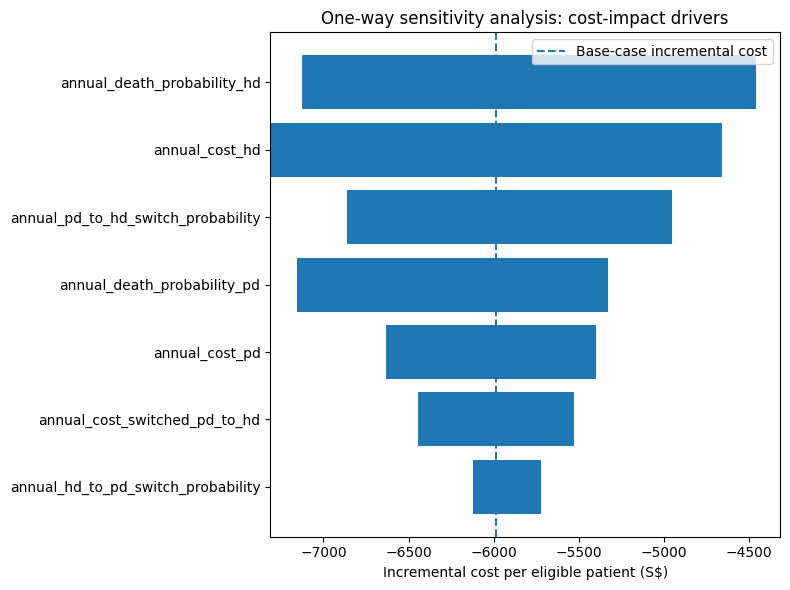

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_tornado_incremental_cost.png')

In [21]:
plot_df = tornado.dropna(subset=["min_incremental_cost", "max_incremental_cost"]).copy()
plot_df = plot_df.loc[plot_df["range"].abs() > 1e-9].copy()

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(plot_df))
left = plot_df["min_incremental_cost"]
width = plot_df["max_incremental_cost"] - plot_df["min_incremental_cost"]

plt.barh(y_pos, width, left=left)
plt.axvline(base_incremental["incremental_cost"], linestyle="--", label="Base-case incremental cost")
plt.yticks(y_pos, plot_df["parameter"])
plt.xlabel("Incremental cost per eligible patient (S$)")
plt.title("One-way sensitivity analysis: cost-impact drivers")
plt.legend()
save_figure("figure_tornado_incremental_cost.png")

## 12. Threshold analysis: annual PD cost

This analysis asks:

> At what annual PD cost would increased PD uptake stop being cost-saving compared with current practice?

This is useful because the model conclusion is mainly driven by the difference between annual HD and annual PD costs.

In [22]:
def incremental_cost_at_pd_cost(pd_annual_cost):
    result = evaluate_with_overrides("annual_cost_pd", float(pd_annual_cost))
    return result["incremental_cost"]

pd_cost_range = np.linspace(0, 60000, 121)
threshold_records = []
for pd_cost in pd_cost_range:
    inc_cost = incremental_cost_at_pd_cost(pd_cost)
    threshold_records.append({
        "annual_pd_cost": pd_cost,
        "incremental_cost_per_patient": inc_cost
    })

threshold_df = pd.DataFrame(threshold_records)

threshold_df["abs_incremental_cost"] = threshold_df["incremental_cost_per_patient"].abs()
nearest = threshold_df.loc[threshold_df["abs_incremental_cost"].idxmin()]
break_even_pd_cost = nearest["annual_pd_cost"]
break_even_inc_cost = nearest["incremental_cost_per_patient"]

threshold_summary = pd.DataFrame([{
    "threshold_parameter": "annual_pd_cost",
    "approximate_break_even_annual_pd_cost": break_even_pd_cost,
    "incremental_cost_at_nearest_point": break_even_inc_cost,
    "base_case_annual_pd_cost": get_param_value(base_params, "annual_cost_pd"),
    "base_case_annual_hd_cost": get_param_value(base_params, "annual_cost_hd"),
    "notes": "Approximate grid-based threshold. Refine with root-finding if exact precision is needed."
}])

write_output(threshold_df.drop(columns=["abs_incremental_cost"]), "threshold_analysis_pd_cost_grid.csv")
write_output(threshold_summary, "threshold_analysis_pd_cost_summary.csv")

display(threshold_summary.round(2))

Wrote threshold_analysis_pd_cost_grid.csv: 121 rows
Wrote threshold_analysis_pd_cost_summary.csv: 1 rows


,threshold_parameter,approximate_break_even_annual_pd_cost,incremental_cost_at_nearest_point,base_case_annual_pd_cost,base_case_annual_hd_cost,notes
0,annual_pd_cost,38000.0,63.14,18840.0,37800.0,Approximate grid-based threshold. Refine with ...


Wrote figure_threshold_analysis_pd_cost.png


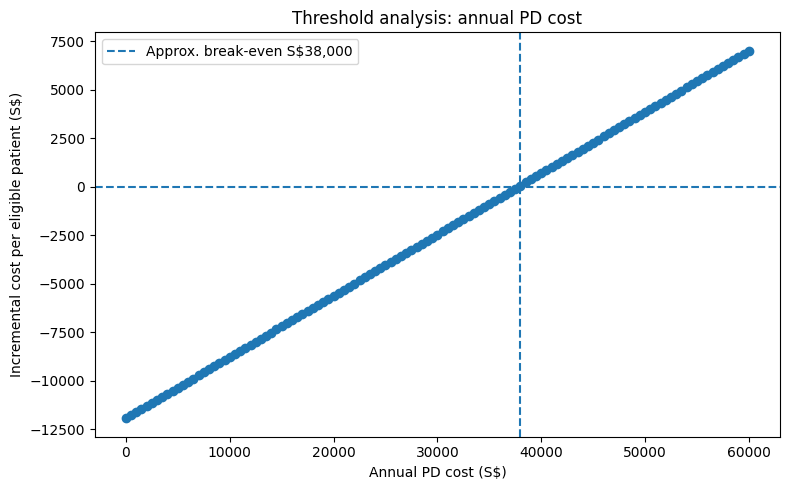

PosixPath('/Users/marissa/Desktop/portfolio/HD_PD_HTA_PROJECT/outputs/figure_threshold_analysis_pd_cost.png')

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["annual_pd_cost"], threshold_df["incremental_cost_per_patient"], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(break_even_pd_cost, linestyle="--", label=f"Approx. break-even S${break_even_pd_cost:,.0f}")
plt.xlabel("Annual PD cost (S$)")
plt.ylabel("Incremental cost per eligible patient (S$)")
plt.title("Threshold analysis: annual PD cost")
plt.legend()
save_figure("figure_threshold_analysis_pd_cost.png")

## 13. Summary tables



In [24]:
input_summary_rows = []

for param in [
    "eligible_patients_per_year",
    "current_pd_uptake",
    "target_pd_uptake",
    "annual_cost_hd",
    "annual_cost_pd",
    "annual_cost_switched_pd_to_hd",
    "health_state_utility_hd",
    "health_state_utility_pd",
    "health_state_utility_switched_pd_to_hd",
    "annual_death_probability_hd",
    "annual_death_probability_pd",
    "annual_pd_to_hd_switch_probability",
    "annual_hd_to_pd_switch_probability",
]:
    row = base_params.loc[base_params["parameter"] == param].iloc[0]
    input_summary_rows.append({
        "parameter": param,
        "base_value": row["base_value"],
        "low_value": row["low_value"],
        "high_value": row["high_value"],
        "unit": row["unit"],
        "source_key": row["source_key"],
        "notes": row["notes"]
    })

report_model_input_summary = pd.DataFrame(input_summary_rows)
write_output(report_model_input_summary, "report_table_model_input_summary.csv")
display(report_model_input_summary)

Wrote report_table_model_input_summary.csv: 13 rows


,parameter,base_value,low_value,high_value,unit,source_key,notes
0,eligible_patients_per_year,1314.00,NaN,NaN,patients_per_year,MOH_PD_POLICY,Derived as incident patients per year multipli...
1,current_pd_uptake,0.19,NaN,NaN,proportion,MOH_PD_POLICY,Current practice PD uptake anchor among new di...
2,target_pd_uptake,0.30,NaN,NaN,proportion,MOH_PD_POLICY,Policy target PD uptake among new dialysis pat...
3,annual_cost_hd,37800.00,33600.00,42000.00,SGD_per_year,DUKE_MYKIDNEY_COSTS,Annual HD cost used in base Markov model.
4,annual_cost_pd,18840.00,16800.00,20700.00,SGD_per_year,KHAN_2022_ECONOMICS,Annual blended PD cost used in base Markov model.
5,annual_cost_switched_pd_to_hd,37800.00,33600.00,42000.00,SGD_per_year,DUKE_MYKIDNEY_COSTS,Assumed equal to annual HD cost after PD techn...
6,health_state_utility_hd,0.58,0.44,0.71,utility_weight,COOPER_2020_UTILITIES,Placeholder utility for first-pass model. Coop...
7,health_state_utility_pd,0.62,0.53,0.72,utility_weight,YANG_2018_PD_HRQoL,Placeholder utility for first-pass model. Keep...
8,health_state_utility_switched_pd_to_hd,0.56,0.44,0.71,utility_weight,COOPER_2020_UTILITIES,Assumed slightly lower than stable HD due to p...
9,annual_death_probability_hd,0.12,0.08,0.18,annual_probability,KHOO_2022_OUTCOMES,Base case assumes equal annual mortality for H...


In [25]:
report_ce_results = summary_base[[
    "strategy",
    "total_cost",
    "total_life_years",
    "total_qalys",
    "final_alive",
    "final_dead"
]].copy()

report_ce_results["total_cost"] = report_ce_results["total_cost"].round(2)
report_ce_results["total_life_years"] = report_ce_results["total_life_years"].round(4)
report_ce_results["total_qalys"] = report_ce_results["total_qalys"].round(4)
report_ce_results["final_alive"] = report_ce_results["final_alive"].round(4)
report_ce_results["final_dead"] = report_ce_results["final_dead"].round(4)

write_output(report_ce_results, "report_table_base_case_economic_results.csv")

report_incremental_results = ce_comparison_base.copy()
for col in ["incremental_cost", "incremental_qalys", "incremental_life_years", "icer_cost_per_qaly"]:
    report_incremental_results[col] = report_incremental_results[col].round(4)

write_output(report_incremental_results, "report_table_incremental_results.csv")

display(report_ce_results)
display(report_incremental_results)

Wrote report_table_base_case_economic_results.csv: 2 rows
Wrote report_table_incremental_results.csv: 1 rows


,strategy,total_cost,total_life_years,total_qalys,final_alive,final_dead
0,current_practice,137176.31,3.9356,2.3031,0.5277,0.4723
1,increased_pd_uptake,131190.61,3.9356,2.3135,0.5277,0.4723


,intervention,comparator,incremental_cost,incremental_qalys,incremental_life_years,icer_cost_per_qaly,interpretation
0,increased_pd_uptake,current_practice,-5985.7004,0.0105,0.0,NaN,Dominant: lower cost and higher QALYs


In [26]:
report_bia_summary = bia_cumulative_summary.copy()
for col in ["five_year_incremental_cost", "five_year_incremental_qalys", "five_year_incremental_life_years", "year_5_incremental_cost", "year_5_cumulative_incremental_cost"]:
    report_bia_summary[col] = report_bia_summary[col].round(2)

write_output(report_bia_summary, "report_table_budget_impact_summary.csv")
display(report_bia_summary)

Wrote report_table_budget_impact_summary.csv: 3 rows


,scenario,five_year_incremental_cost,five_year_incremental_qalys,five_year_incremental_life_years,year_5_incremental_cost,year_5_cumulative_incremental_cost
0,base_pd_adoption,-15890210.78,30.78,-0.0,-5913747.31,-15890210.78
1,high_pd_adoption,-32737986.58,63.30,-0.0,-11799259.71,-32737986.58
2,low_pd_adoption,-12364066.72,23.96,-0.0,-4521082.62,-12364066.72


In [27]:
uncertainty_summary = input_quality.groupby("input_quality_flag", as_index=False).agg(
    n_inputs=("parameter", "count")
)

write_output(uncertainty_summary, "report_table_uncertainty_summary.csv")
display(uncertainty_summary)

Wrote report_table_uncertainty_summary.csv: 5 rows


,input_quality_flag,n_inputs
0,Derived input,8
1,High uncertainty / assumption,7
2,Other,1
3,Singapore peer-reviewed or sector evidence,10
4,Singapore public source,9


## 14. Automatic plain-language interpretation



In [28]:
inc = ce_comparison_base.iloc[0]
bia_base = bia_cumulative_summary.loc[bia_cumulative_summary["scenario"] == "base_pd_adoption"].iloc[0]

interpretation_lines = []

interpretation_lines.append("Base-case economic evaluation interpretation")
interpretation_lines.append("------------------------------------------------")
interpretation_lines.append(
    f"Compared with current practice, increased PD uptake changed five-year cost by S${inc['incremental_cost']:,.2f} per eligible patient."
)
interpretation_lines.append(
    f"It changed five-year QALYs by {inc['incremental_qalys']:.4f} per eligible patient."
)
interpretation_lines.append(
    f"Base-case interpretation: {inc['interpretation']}."
)
interpretation_lines.append("")
interpretation_lines.append("Budget impact interpretation")
interpretation_lines.append("------------------------------------------------")
interpretation_lines.append(
    f"In the base adoption scenario, the five-year cumulative incremental budget impact was S${bia_base['five_year_incremental_cost']:,.2f}."
)
interpretation_lines.append(
    "Negative incremental cost means increased PD uptake is cost-saving relative to current practice under the model assumptions."
)
interpretation_lines.append("")
interpretation_lines.append("Important caution")
interpretation_lines.append("------------------------------------------------")
interpretation_lines.append(
    "The result is mainly driven by publicly available cost proxies, assumed PD suitability, assumed mortality, assumed PD-to-HD switching and literature-based utility values. It should be interpreted as a transparent portfolio model rather than a definitive funding recommendation."
)

interpretation_text = "\n".join(interpretation_lines)
interpretation_path = OUTPUTS / "model_interpretation_notes.txt"
interpretation_path.write_text(interpretation_text, encoding="utf-8")

print(interpretation_text)
print(f"\nWrote {interpretation_path.name}")

Base-case economic evaluation interpretation
------------------------------------------------
Compared with current practice, increased PD uptake changed five-year cost by S$-5,985.70 per eligible patient.
It changed five-year QALYs by 0.0105 per eligible patient.
Base-case interpretation: Dominant: lower cost and higher QALYs.

Budget impact interpretation
------------------------------------------------
In the base adoption scenario, the five-year cumulative incremental budget impact was S$-15,890,210.78.
Negative incremental cost means increased PD uptake is cost-saving relative to current practice under the model assumptions.

Important caution
------------------------------------------------
The result is mainly driven by publicly available cost proxies, assumed PD suitability, assumed mortality, assumed PD-to-HD switching and literature-based utility values. It should be interpreted as a transparent portfolio model rather than a definitive funding recommendation.

Wrote model_int

## 15. Output inventory



In [29]:
output_inventory = []

for path in sorted(OUTPUTS.glob("*")):
    output_inventory.append({
        "file": path.name,
        "type": path.suffix.replace(".", ""),
        "created_at": datetime.now().isoformat(timespec="seconds")
    })

output_inventory_df = pd.DataFrame(output_inventory)
write_output(output_inventory_df, "output_inventory.csv")

display(output_inventory_df)

print("\nDone. The modelling notebook has generated report-ready tables and figures in the outputs folder.")

Wrote output_inventory.csv: 31 rows


,file,type,created_at
0,budget_impact_annual_results.csv,csv,2026-05-11T14:28:55
1,budget_impact_cohort_cycle_details.csv,csv,2026-05-11T14:28:55
2,budget_impact_cumulative_summary.csv,csv,2026-05-11T14:28:55
3,economic_evaluation_incremental_results_base_c...,csv,2026-05-11T14:28:55
4,economic_evaluation_incremental_results_scaled...,csv,2026-05-11T14:28:55
5,economic_evaluation_summary_base_case.csv,csv,2026-05-11T14:28:55
6,economic_evaluation_summary_scaled_annual_coho...,csv,2026-05-11T14:28:55
7,figure_annual_budget_impact.png,png,2026-05-11T14:28:55
8,figure_cost_per_patient_base_case.png,png,2026-05-11T14:28:55
9,figure_cumulative_budget_impact.png,png,2026-05-11T14:28:55



Done. The modelling notebook has generated report-ready tables and figures in the outputs folder.
